 ## **Name of the team on GitHub Classroom:** GroupB-B1

**Member 1:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** | 148396 |
| **Name** | Ida Aluso Masheti |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** Set up the notebook environment and performed EDA on the dataset. I learned how to compute distribution metrics such as skewness and kurtosis and ensure identifier columns like `account_id` are excluded so they do not skew the clustering metrics.  I also learned how to interpret pairplot and scatterplot results. I was also able to learn what alpha is and how it works.|

**Member 2:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** | 169884 |
| **Name** | Derby Muchiri |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** I handled the data preprocessing part of the lab, which included feature selection, handling missing data, and scaling. By doing this, I learned how to evaluate feature redundancy using a correlation heatmap, how to impute missing values using the median to handle random missingness, and why applying StandardScaler is necessary.|

**Member 3:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** | 170160 |
| **Name** | Collins Kibiru |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

**Member 4:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Brian Kioko |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

**Member 5:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Charles Kabuga |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

**Member 6:**

| **Details** | **Comment** |
|:---|:---|
| **Student ID** |  |
| **Name** | Bridgette Juma |
| **What part of the lab did you personally<br/>contribute to (provide a link to the<br/>branch(es)), and what did you learn from it?** | >**Contribution & Key Learnings:** |

##Install dependencies and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

#Load csv data
df = pd.read_csv("bank_wealth_management.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 700 rows, 7 columns


,account_id,branch_region,account_balance_kes,transactions_per_month,avg_transaction_amount_kes,years_as_customer,digital_banking_usage_score
0,1,Nairobi,20714.0,49.5,2526.0,1.9,76.503049
1,2,Coast,43171.0,7.9,4248.0,6.2,67.441691
2,3,Nairobi,51082.0,19.8,4999.0,5.4,65.498439
3,4,Nairobi,45884.0,17.4,3173.0,1.1,100.000000
4,5,Nairobi,726439.0,18.4,31945.0,5.6,60.002902


## Identifying and checking for missing values

In [ ]:
#Check for missing values count
df.info()
print("\n Missing values in each column:")
print(df.isna().sum())

#Define numerical columns but exclue unique identifiers
num_cols = df.select_dtypes(include=['number']).columns.drop('account_id').tolist()
print(num_cols)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   700 non-null    int64  
 1   branch_region                700 non-null    object 
 2   account_balance_kes          700 non-null    float64
 3   transactions_per_month       700 non-null    float64
 4   avg_transaction_amount_kes   700 non-null    float64
 5   years_as_customer            700 non-null    float64
 6   digital_banking_usage_score  671 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 38.4+ KB

 Missing values in each column:
account_id                      0
branch_region                   0
account_balance_kes             0
transactions_per_month          0
avg_transaction_amount_kes      0
years_as_customer               0
digital_banking_usage_score    29
dtype: int64
['account_balance_kes', 'tr

*account_id* is a unique PK thus why it is excluded from stats summaries, correlation, and distance calculations. This prevents skenwness in the distance calculations.

digital_banking_usage_score: Has 29 missing values as per the count provided in the results of the check for missing values. These will require imputation.

## Distribution Calculations

In [ ]:
# Mean, std, median, skewness, and kurtosis

dist_summary = df[num_cols].describe().T
dist_summary["skewness"] = df[num_cols].apply(lambda x: skew(x.dropna(), bias=False))
dist_summary["kurtosis"] = df[num_cols].apply(lambda x: kurtosis(x.dropna(), bias=False))
dist_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
account_balance_kes,700.0,521846.72,1190473.51,1000.0,25702.00,42781.50,506207.50,6282032.0,2.95,7.72
transactions_per_month,700.0,16.60,11.14,0.0,8.40,15.90,22.62,50.8,0.55,-0.02
avg_transaction_amount_kes,700.0,14677.63,28217.84,100.0,1578.25,3218.50,16769.25,163062.0,2.96,8.43
years_as_customer,700.0,4.85,3.43,0.1,1.90,4.40,7.20,19.0,0.67,0.07
digital_banking_usage_score,671.0,54.22,25.01,0.0,37.38,54.72,72.10,100.0,-0.08,-0.61


As per the results above:

*account_balance_kes*: Shows a high right-skewness (s>0) with balances ranging from 1000 KES to 6.28M KES thus a high concentration on the wealth end.

*transactions_per month*: Shows a uniform distribution with a mean of 16.6 transactions per month


## EDA

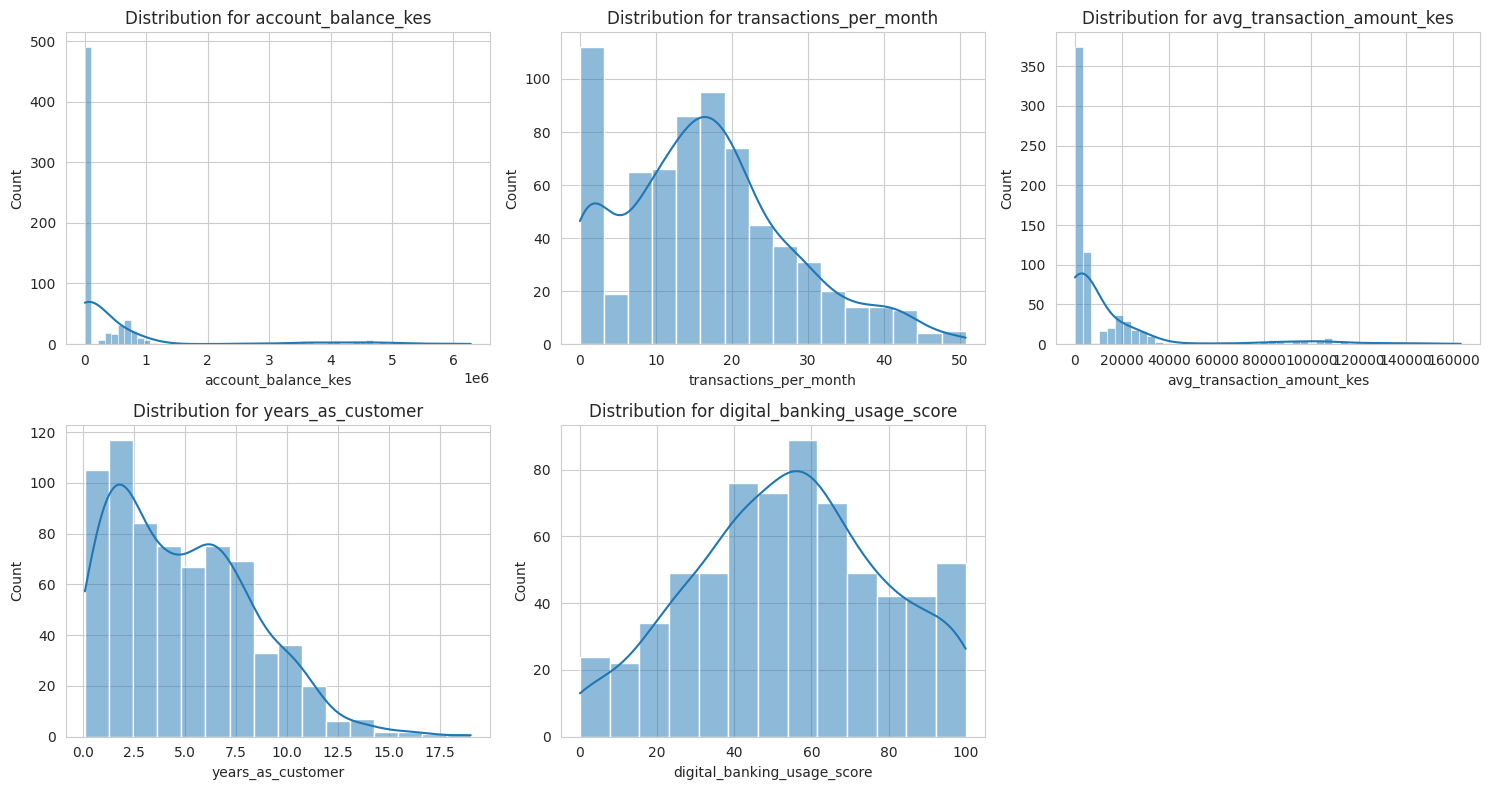

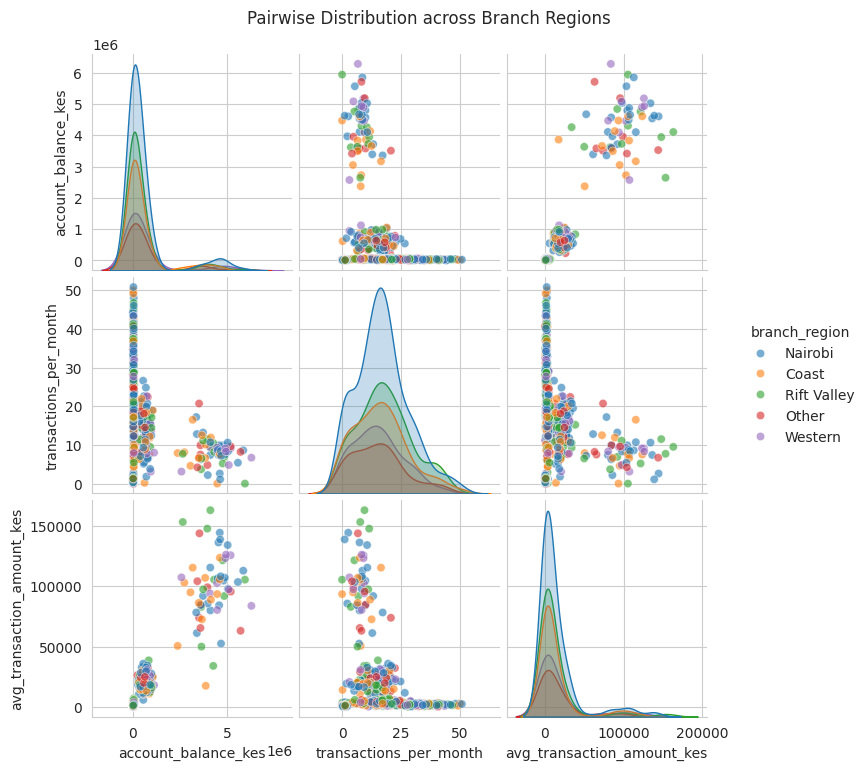

In [ ]:
#Histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(df[col], kde=True, ax=axes[i], color="#1f77b4")
  axes[i].set_title(f"Distribution for {col}")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

#Scatter matrix that is coloured by region
sns.pairplot(
    df,
    vars=['account_balance_kes', 'transactions_per_month', 'avg_transaction_amount_kes'],
    hue='branch_region',
    plot_kws={'alpha': 0.6}
)
plt.suptitle("Pairwise Distribution across Branch Regions", y=1.02)
plt.show()

*account_balance* and *avg_transaction_amount_kes* show high right skewness with a large majority of customers at the lower values and the tail end having high-net-worth outliers

*transactions_per_month, years_as_customer*, and *digital_banking* show more continuous distributions around their means thus indicationg diverse engagement.

Normalization/Standardization is needed prior to K-Means due to the financial features having larger metrics.

# Preprocessing Pipeline

## Check Correlated Features

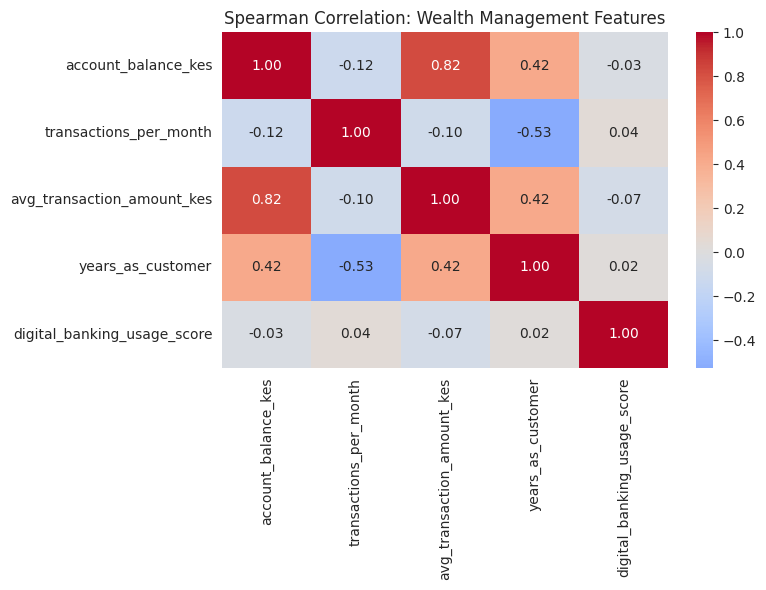

In [ ]:
# Calculate Spearman correlation (better for skewed financial distributions than Pearson)
corr_matrix = df[num_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Spearman Correlation: Wealth Management Features")
plt.tight_layout()
plt.show()

Interpretation:

Based on the heatmap, there is a strong positive correlation (0.82) between account balance and average transaction amount, showing that customers with higher balances generally make larger transactions. There is also a moderate negative correlation (-0.53) between monthly transactions and years as a customer, suggesting newer customers transact more frequently than older ones. Finally, the digital banking score is almost completely independent of the other variables because correlations near 0. we will retain all features because they still measure different customer behaviors for example saved wealth versus spending size and are not perfectly redundant despite the high correlation.

# Handling Missing data and feature selection


During EDA, we noted 29 missing values in digital_banking_usage_score. We determined this is likely random missingness rather than structural missingness because it is probably just a temporary system that failed to record the score, rather than the customer not owning a smartphone at all. Therefore, we imputed these missing values using the column's median rather than dropping the rows so we don't lose data. Finally, as noted earlier, account_id and branch_region are excluded from the clustering features.

In [ ]:
# Impute random missing values with the median
median_score = df['digital_banking_usage_score'].median()
df['digital_banking_usage_score'] = df['digital_banking_usage_score'].fillna(median_score)

# Confirm no more missing values exist in our numeric columns
print("Missing values after median imputation:")
print(df[num_cols].isna().sum())

# Create our final feature matrix (X) for clustering
X = df[num_cols].copy()
X.head()

Missing values after median imputation:
account_balance_kes            0
transactions_per_month         0
avg_transaction_amount_kes     0
years_as_customer              0
digital_banking_usage_score    0
dtype: int64


,account_balance_kes,transactions_per_month,avg_transaction_amount_kes,years_as_customer,digital_banking_usage_score
0,20714.0,49.5,2526.0,1.9,76.503049
1,43171.0,7.9,4248.0,6.2,67.441691
2,51082.0,19.8,4999.0,5.4,65.498439
3,45884.0,17.4,3173.0,1.1,100.000000
4,726439.0,18.4,31945.0,5.6,60.002902


##Preprocessing pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (Original varying ranges):")
display(X.describe().loc[["mean", "std", "min", "max"]].round(2))

print("\nAfter scaling (Confirming mean ≈ 0 and std ≈ 1 for all features):")
# We convert the numpy array back to a dataframe just to show the describe statistics easily
display(pd.DataFrame(X_scaled, columns=X.columns).describe().loc[["mean", "std", "min", "max"]].round(2))

Before scaling (Original varying ranges):


,account_balance_kes,transactions_per_month,avg_transaction_amount_kes,years_as_customer,digital_banking_usage_score
mean,521846.72,16.60,14677.63,4.85,54.24
std,1190473.51,11.14,28217.84,3.43,24.49
min,1000.00,0.00,100.00,0.10,0.00
max,6282032.00,50.80,163062.00,19.00,100.00



After scaling (Confirming mean ≈ 0 and std ≈ 1 for all features):


,account_balance_kes,transactions_per_month,avg_transaction_amount_kes,years_as_customer,digital_banking_usage_score
mean,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.44,-1.49,-0.52,-1.39,-2.22
max,4.84,3.07,5.26,4.13,1.87


**Interpretation**

We used StandardScaler because our columns have very different number ranges. For example, account_balance_kes has millions, while years_as_customer is mostly under 20. Hence, by applying StandardScaler, we were able to adjust all the data so that every feature has a mean of 0 and a standard deviation of 1. This ensured that features with huge numbers like account balances did not overpower features with small numbers like years as a customer during clustering.

# Determining k & Validity Metrics

We now determine the optimal number of clusters ($k$) for K-Means, testing values from $k=2$ to $k=10$. We use the elbow method (inertia) alongside three validity metrics — Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index — to justify our final choice.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

k_range = range(2, 11)

inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

metrics_df = pd.DataFrame({
    "k": list(k_range),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores,
    "Davies-Bouldin Index": db_scores,
    "Calinski-Harabasz Index": ch_scores
})

display(metrics_df.round(4))


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_range, inertias, marker="o", color="#1f77b4")
axes[0, 0].set_title("Elbow Method: Inertia vs k")
axes[0, 0].set_xlabel("Number of Clusters (k)")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_xticks(list(k_range))

axes[0, 1].plot(k_range, silhouette_scores, marker="o", color="green")
axes[0, 1].set_title("Silhouette Score vs k (higher is better)")
axes[0, 1].set_xlabel("Number of Clusters (k)")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_xticks(list(k_range))

axes[1, 0].plot(k_range, db_scores, marker="o", color="red")
axes[1, 0].set_title("Davies-Bouldin Index vs k (lower is better)")
axes[1, 0].set_xlabel("Number of Clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin Index")
axes[1, 0].set_xticks(list(k_range))

axes[1, 1].plot(k_range, ch_scores, marker="o", color="purple")
axes[1, 1].set_title("Calinski-Harabasz Index vs k (higher is better)")
axes[1, 1].set_xlabel("Number of Clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz Index")
axes[1, 1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k_silhouette = metrics_df.loc[metrics_df["Silhouette Score"].idxmax(), "k"]
best_k_db = metrics_df.loc[metrics_df["Davies-Bouldin Index"].idxmin(), "k"]
best_k_ch = metrics_df.loc[metrics_df["Calinski-Harabasz Index"].idxmax(), "k"]

print(f"Best k by Silhouette Score:        {best_k_silhouette}")
print(f"Best k by Davies-Bouldin Index:    {best_k_db}")
print(f"Best k by Calinski-Harabasz Index: {best_k_ch}")


**Interpretation**

[TODO: Fill this in once you run the cells above and see the actual numbers/plots. A template you can adapt:]

The elbow plot shows inertia decreasing sharply up to around $k=X$, after which the rate of decrease flattens, suggesting diminishing returns from additional clusters beyond this point. The Silhouette Score peaks at $k=X$, indicating the most well-separated and internally cohesive clusters at this value. The Davies-Bouldin Index is lowest at $k=X$, confirming good separation between cluster centroids relative to their spread. The Calinski-Harabasz Index is highest at $k=X$, further supporting this choice by showing strong between-cluster variance relative to within-cluster variance.

Based on the convergence of these metrics, we select $k=X$ as the optimal number of clusters for segmenting customers in this wealth management dataset.